#  Electricity Consumption Forecasting

This notebook demonstrates a complete machine learning workflow for predicting hourly electricity consumption. We'll use time-series features, lag variables, and rolling statistics to forecast energy usage.

## Project Overview
- **Goal**: Predict next-hour electricity consumption (kWh)
- **Data**: Hourly electricity usage data
- **Approach**: Feature engineering + Machine learning regression models
- **Models**: Ridge Regression, Random Forest, Gradient Boosting

---

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## 2. Load the Dataset

We'll load the electricity consumption data which contains:
- `datetime`: Timestamp of each measurement
- `energy_kwh`: Electricity consumption in kilowatt-hours

In [2]:
data = pd.read_csv("electricity.csv", parse_dates = ["datetime"])
data.head()

,datetime,energy_kwh
0,2020-01-01 00:00:00,2.14
1,2020-01-01 01:00:00,2.05
2,2020-01-01 02:00:00,1.98
3,2020-01-01 03:00:00,1.92
4,2020-01-01 04:00:00,1.87


## 3. Feature Engineering - Temporal Features

Extract time-based features from the datetime column:
- **hour**: Hour of the day (0-23) - captures daily patterns
- **day**: Day of the month (1-31) - captures monthly patterns
- **weekday**: Day of the week (0-6) - captures weekly patterns (Mon=0, Sun=6)
- **month**: Month of the year (1-12) - captures seasonal patterns

In [3]:
data["hour"] = data["datetime"].dt.hour
data["day"] = data["datetime"].dt.day
data["weekday"] = data["datetime"].dt.weekday
data["month"] = data["datetime"].dt.month

## 4. Feature Engineering - Lag Features

Create lag features to capture historical patterns:
- **lag1**: Energy consumption 1 hour ago
- **lag2**: Energy consumption 2 hours ago
- **lag3**: Energy consumption 3 hours ago

These features help the model learn from recent historical values.

In [4]:
data["lag1"] = data["energy_kwh"].shift(1)
data["lag2"] = data["energy_kwh"].shift(2)
data["lag3"] = data["energy_kwh"].shift(3)

## 5. Feature Engineering - Rolling Statistics

Create a rolling mean feature:
- **rolling_mean**: 3-hour moving average of energy consumption

This smooths out short-term fluctuations and captures trends. We then drop rows with NaN values created by shift and rolling operations.

In [5]:
data["rolling_mean"] = data["energy_kwh"].rolling(window=3).mean()
data = data.dropna()

## 6. Inspect the Processed Data

Let's view the dataset with all engineered features:

In [6]:
data

,datetime,energy_kwh,hour,day,weekday,month,lag1,lag2,lag3,rolling_mean
3,2020-01-01 03:00:00,1.92,3,1,2,1,1.98,2.05,2.14,1.983333
4,2020-01-01 04:00:00,1.87,4,1,2,1,1.92,1.98,2.05,1.923333
5,2020-01-01 05:00:00,1.90,5,1,2,1,1.87,1.92,1.98,1.896667
6,2020-01-01 06:00:00,2.10,6,1,2,1,1.90,1.87,1.92,1.956667
7,2020-01-01 07:00:00,2.45,7,1,2,1,2.10,1.90,1.87,2.150000
...,...,...,...,...,...,...,...,...,...,...
67,2020-01-03 19:00:00,4.10,19,3,4,1,3.88,3.55,3.42,3.843333
68,2020-01-03 20:00:00,3.95,20,3,4,1,4.10,3.88,3.55,3.976667
69,2020-01-03 21:00:00,3.72,21,3,4,1,3.95,4.10,3.88,3.923333
70,2020-01-03 22:00:00,3.35,22,3,4,1,3.72,3.95,4.10,3.673333


## 7. Train-Test Split

Split the data into training and testing sets:
- **Training**: 80% of the data (earlier time periods)
- **Testing**: 20% of the data (later time periods)

⚠️ **Important**: We maintain temporal order (no shuffling) to ensure realistic time-series evaluation.

In [7]:
train_size = int(len(data) * 0.8)
train = data.iloc[:train_size]
test = data.iloc[train_size:]

## 8. Define Features and Target

Specify which columns to use:
- **Features (X)**: All engineered features (temporal, lag, rolling statistics)
- **Target (y)**: `energy_kwh` - the value we want to predict

Note: We exclude the `datetime` column from features as ML models cannot directly process datetime objects.

In [8]:
features = ["hour", "day", "weekday", "month", "lag1", "lag2", "lag3", "rolling_mean"]
target = "energy_kwh"

## 9. Prepare X and y for Training

Separate features (X) and target variable (y) for both training and testing sets:

In [9]:
X_train = train[features]
X_test = test[features]

y_train = train[target]
y_test = test[target]

## 10. Build and Train Initial Model

Create a machine learning pipeline with:
1. **StandardScaler**: Normalizes features to have mean=0 and std=1
2. **Ridge Regression**: Linear model with L2 regularization

The pipeline ensures consistent preprocessing during training and prediction.

In [10]:
pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])

## 11. Make Predictions on Test Set

Use the trained model to predict electricity consumption for the test period:

In [11]:
y_pred = pipeline.predict(X_test)

## 12. Evaluate Model Performance

Calculate key regression metrics:

### Mean Absolute Error (MAE)
Average absolute difference between predicted and actual values. Lower is better.

In [12]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.10850384141452131


### Mean Squared Error (MSE)
Penalizes larger errors more heavily than MAE. Lower is better.

In [13]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.01644081513239573


### R² Score (Coefficient of Determination)
Proportion of variance in the target explained by the model. Range: 0 to 1, higher is better.

In [14]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.8071435551356434


## 13. Hyperparameter Tuning with GridSearchCV

Optimize the Ridge regression's alpha parameter (regularization strength):
- Tests alpha values: [0.001, 0.01, 0.1, 1, 10, 100]
- Uses 5-fold cross-validation
- Optimizes for negative MAE (lower error = better)

In [15]:
param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error"
)

### Run Grid Search

Fit the grid search to find the best hyperparameters:

In [16]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', Ridge())]),
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='neg_mean_absolute_error')

### Display Best Parameters

Show the optimal alpha value and corresponding cross-validation score:

In [17]:
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'model__alpha': 0.001}
Best CV Score: -0.0008075936898475239


## 14. Evaluate Tuned Model

Get predictions from the best model found by GridSearchCV:

In [18]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

### Tuned Model - Mean Absolute Error

In [19]:
mae_best = mean_absolute_error(y_test, y_pred_best)
print("Tuned Mean Absolute Error:", mae_best)

Tuned Mean Absolute Error: 0.000567140784802657


### Tuned Model - Mean Squared Error

In [20]:
mse_best = mean_squared_error(y_test, y_pred_best)
print("Tuned Mean Squared Error:", mse_best)

Tuned Mean Squared Error: 4.725905571721119e-07


### Tuned Model - R² Score

In [21]:
r2_best = r2_score(y_test, y_pred_best)
print("Tuned R2 Score:", r2_best)

Tuned R2 Score: 0.9999944563493964


## 15. Visualizations

### 15.1 Actual vs Predicted Time Series

Compare actual and predicted values over time to assess model performance visually:

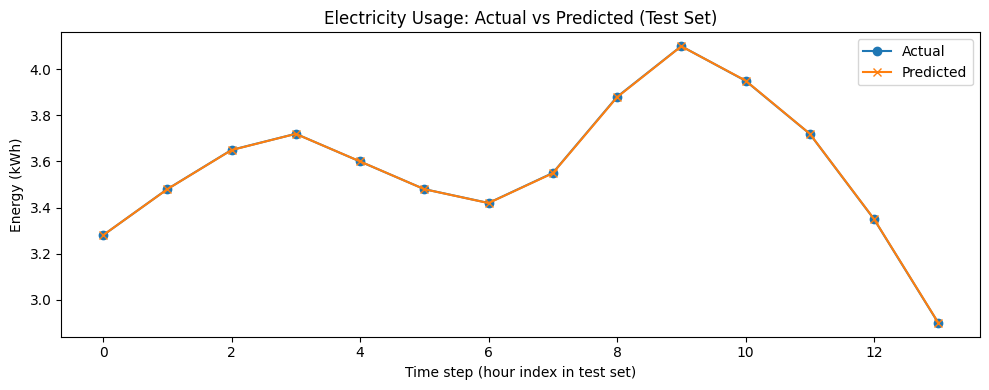

In [22]:
plt.figure(figsize=(10, 4))
plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred_best, label="Predicted", marker='x')
plt.legend()
plt.title("Electricity Usage: Actual vs Predicted (Test Set)")
plt.xlabel("Time step (hour index in test set)")
plt.ylabel("Energy (kWh)")
plt.tight_layout()
plt.show()


### 15.2 Residuals Plot

Residuals = Actual - Predicted. Ideally, residuals should be randomly distributed around zero with no patterns.

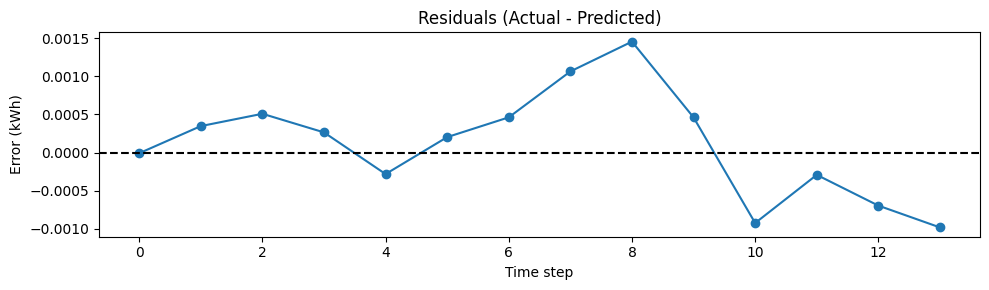

In [23]:
residuals = y_test.values - y_pred_best

plt.figure(figsize=(10, 3))
plt.plot(residuals, marker='o')
plt.title("Residuals (Actual - Predicted)")
plt.xlabel("Time step")
plt.ylabel("Error (kWh)")
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


### 15.3 Actual vs Predicted Scatter Plot

Points should cluster around the red diagonal line (perfect predictions). Deviations show prediction errors.

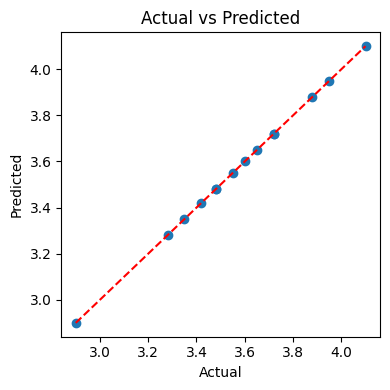

In [24]:
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # ideal line
plt.tight_layout()
plt.show()

## 16. Model Comparison

Compare three different regression algorithms:
1. **Ridge Regression**: Linear model with L2 regularization (optimal alpha from tuning)
2. **Random Forest**: Ensemble of decision trees (200 estimators)
3. **Gradient Boosting**: Sequential ensemble method (200 estimators)

Define models with their respective pipelines:

In [25]:
models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=0.001))  # from your tuning
    ]),
    "RandomForest": Pipeline([
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]),
    "GradientBoosting": Pipeline([
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            random_state=42
        ))
    ])
}

results = {}

### Train and Evaluate All Models

Train each model and collect performance metrics for comparison:

In [26]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_m = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred_m)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_m))
    r2 = r2_score(y_test, y_pred_m)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

results

{'Ridge': {'MAE': 0.000567140784802657,
  'RMSE': 0.0006874522217377088,
  'R2': 0.9999944563493964},
 'RandomForest': {'MAE': 0.07978928571428281,
  'RMSE': 0.10441476274249273,
  'R2': 0.8721105785574114},
 'GradientBoosting': {'MAE': 0.07483679366599698,
  'RMSE': 0.09912722135515235,
  'R2': 0.8847352066776608}}

### Display Model Comparison Results

Compare all models side-by-side to identify the best performer:

In [27]:
for name, metrics in results.items():
    print(f"{name}:")
    print(f"  MAE:  {metrics['MAE']:.4f}")
    print(f"  RMSE: {metrics['RMSE']:.4f}")
    print(f"  R2:   {metrics['R2']:.4f}")
    print()

Ridge:
  MAE:  0.0006
  RMSE: 0.0007
  R2:   1.0000

RandomForest:
  MAE:  0.0798
  RMSE: 0.1044
  R2:   0.8721

GradientBoosting:
  MAE:  0.0748
  RMSE: 0.0991
  R2:   0.8847



## 17. Save the Best Model

Save the trained model to disk for later use in production or the Streamlit app:
- Uses `joblib` for efficient serialization
- Creates `electricity_forecaster.pkl` file
- Can be loaded later without retraining

In [28]:
import pickle

with open("electricity_forecaster.pkl", "wb") as f:
    pickle.dump(best_model, f)